# 1. Big Data Acquisition (Lending Club)
**Objective:** In this section, we fetch a large-scale financial dataset from **Lending Club** using `kagglehub`. Handling over **2 million rows** of real-world loan data requires robust loading techniques. We use `low_memory=False` to ensure all data types are correctly identified during the initial read.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder


print("Downloading Lending Club dataset from Kaggle...")
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

df = pd.read_csv(f"{path}/loan.csv", low_memory=False)

display(df.head())
print(f"Dataset shape: {df.shape}")

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Dataset shape: (2260668, 145)


# 2. Advanced Data Preprocessing & Dimensionality Reduction
Working with millions of records requires efficient memory management and feature selection:
* **Handling Missing Values:** We remove columns with more than 30% missing data to preserve model integrity.
* **Domain-Specific Feature Selection:** We select key financial indicators such as `loan_amount`, `int_rate`, `annual_inc`, and `dti` (Debt-to-Income ratio).
* **Target Engineering:** We define a binary `target` (1 for Defaults/Charged-off and 0 for Fully Paid), filtering out ongoing loans to focus on historical performance.
* **Categorical Encoding:** Converting text-based banking grades and terms into numerical formats for the classifier.

In [ ]:
# 1. Drop columns with more than 30% missing values to clean the memory
limit = len(df) * 0.7
df = df.dropna(thresh=limit, axis=1)

# 2. Select only the most important features for credit risk
# These columns are standard in banking (Loan amount, interest, grade, income, dti,...)
keep_cols = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 
             'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'dti', 'revol_util']

df = df[[c for c in keep_cols if c in df.columns]]

# 3. Create the target variable: 1 for Default (Late/Charged Off), 0 for Fully Paid
# We filter for only finished loans
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]
df['target'] = df['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)
df.drop('loan_status', axis=1, inplace=True)

# 4. missing values
df = df.dropna()

# 5. Convert text Categorical to numbers using Label Encoding
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 6. Split the data
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Cleaning done! Remaining rows: {len(df)}")

Cleaning done! Remaining rows: 1227405


## 2.1 Addressing Class Imbalance (Downsampling)
As observed in the initial data exploration, the number of "Fully Paid" loans significantly outweighs the "Default" cases. This **Class Imbalance** leads the model to be biased toward the majority class, resulting in a high overall accuracy but a very low **Recall** for defaults.

To fix this, we implement **Random Under-Sampling** to create a balanced training set. This forces the model to learn the specific characteristics of risky borrowers more effectively.

In [10]:
from sklearn.utils import resample

# 1. Separate the dataset into majority (paid) and minority (default) classes
df_majority = df[df.target == 0]
df_minority = df[df.target == 1]

# 2. Downsample the majority class to match the number of minority class samples
df_majority_downsampled = resample(df_majority, 
                                 replace=False,    # sample without replacement
                                 n_samples=len(df_minority), # match the minority count
                                 random_state=42)

# 3. Combine them back into a balanced DataFrame
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# 4. Use the balanced data for X and y
X = df_balanced.drop('target', axis=1)
y = df_balanced['target']

# 5. Split the balanced data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Balanced Dataset Created!")
print(f"New distribution: \n{y.value_counts()}")

Balanced Dataset Created!
New distribution: 
target
0    241133
1    241133
Name: count, dtype: int64


# 3. Model Training: Random Forest for Credit Risk
We implement a **Random Forest Classifier** with `class_weight='balanced'`. In credit risk datasets, "Default" cases are the minority. Balancing the weights ensures the model learns to identify risky borrowers effectively without being biased toward the majority class (Good loans).

In [11]:
# Set up the Random Forest model and balance the class weights 
# (since bad loans are usually fewer than good ones)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model on our training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Model training complete!")

Model training complete!


# 4. Model Evaluation (ROC-AUC Analysis)
For a dataset of this size, high accuracy can be deceptive. We evaluate the model using the **ROC-AUC Score**, which measures the model's ability to distinguish between defaulters and safe borrowers across various thresholds. This is a standard practice in financial risk management.

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.63      0.64     48227
           1       0.64      0.65      0.64     48227

    accuracy                           0.64     96454
   macro avg       0.64      0.64      0.64     96454
weighted avg       0.64      0.64      0.64     96454

ROC-AUC Score: 0.6917


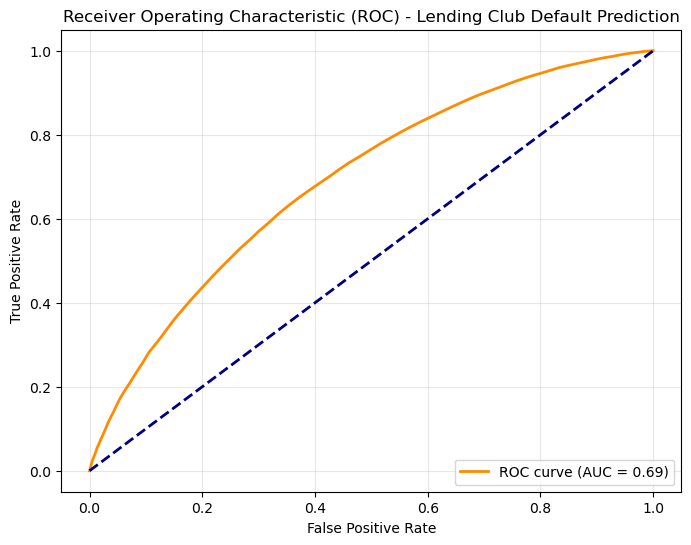

In [12]:
# Print the classification report to see precision, recall, and f1-score
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate the ROC-AUC score to see how well it separates good vs bad customers
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}")

# Plot the ROC curve to visualize the performance
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) - Lending Club Default Prediction')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Feature Importance & Business Insights
A crucial part of financial data science is **Model Interpretability**. We extract and visualize the top 10 factors that contribute most to loan defaults. This allows stakeholders to understand the "why" behind the model's predictions, such as how much an installment amount or an interest rate impacts the risk level.

C:\Users\resod\AppData\Local\Temp\ipykernel_7976\389566373.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='mako')


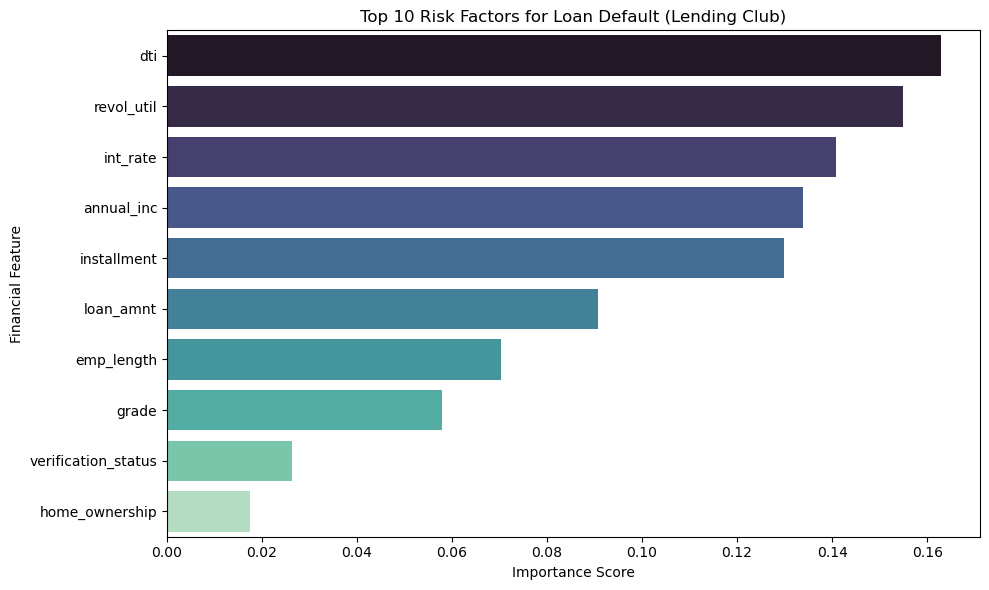

In [13]:
# Get the feature importances to see what the model relied on the most
importances = rf_model.feature_importances_
feature_names = X.columns

# Put them in a neat dataframe for easier reading
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 most important features driving credit risk
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='mako')
plt.title('Top 10 Risk Factors for Loan Default (Lending Club)')
plt.xlabel('Importance Score')
plt.ylabel('Financial Feature')
plt.tight_layout()
plt.show()